In [3]:
# Data Import and Overview
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Data Exploration
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# Checking Missing Values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Data Cleaning
df.drop('Cabin', axis=1, inplace=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [7]:
# Filling missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna('S')
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [8]:
# Importing data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the visual theme for the plots
sns.set_theme(style="whitegrid")

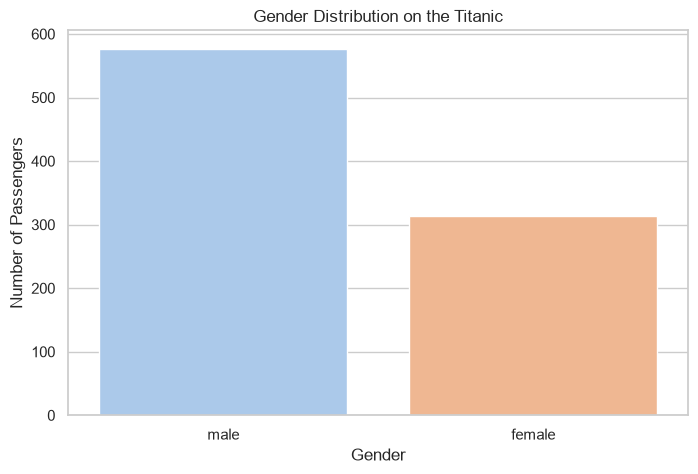

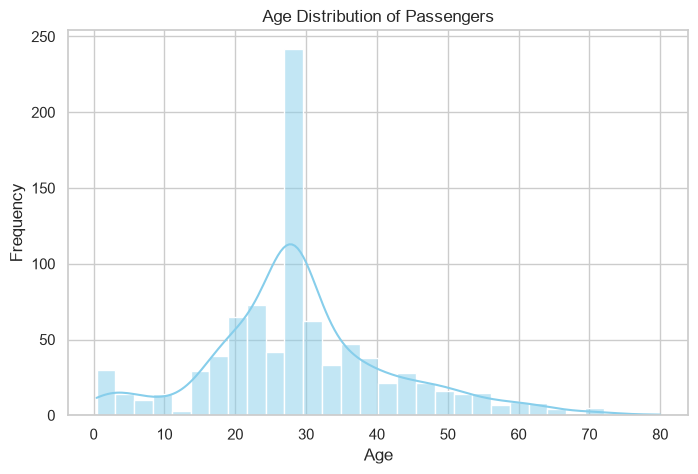

In [ ]:
#  Passenger Profile: Gender Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sex', hue='Sex', palette='pastel', legend=False)
plt.title('Gender Distribution on the Titanic')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()

#  Passenger Profile: Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', kde=True, bins=30, color='skyblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

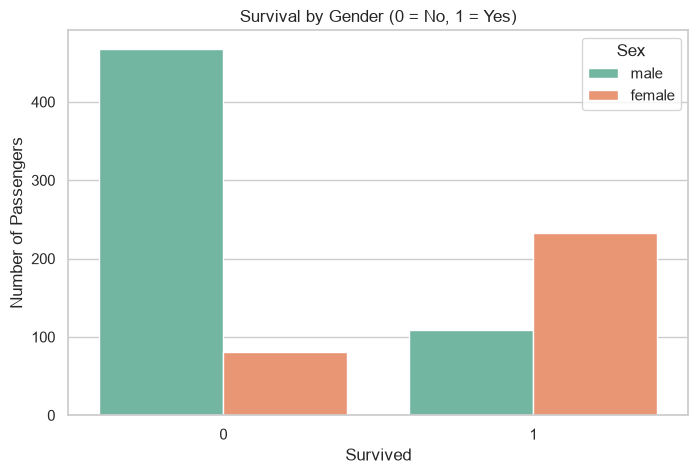

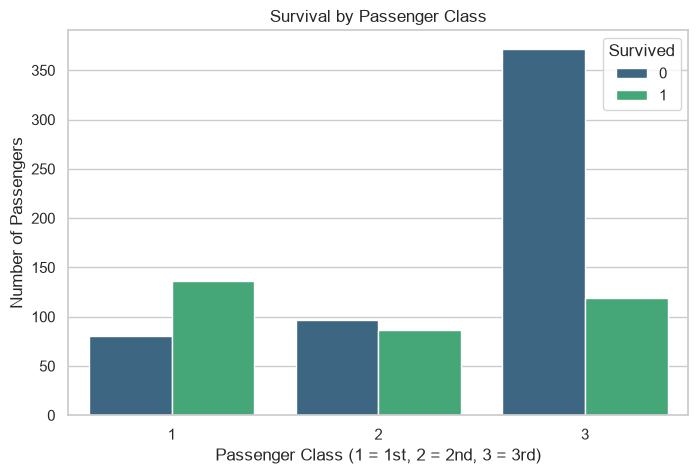

In [11]:
#  Survival Status by Gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Survived', hue='Sex', palette='Set2')
plt.title('Survival by Gender (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.show()

#  Survival Status by Passenger Class
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Pclass', hue='Survived', palette='viridis')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Number of Passengers')
plt.show()

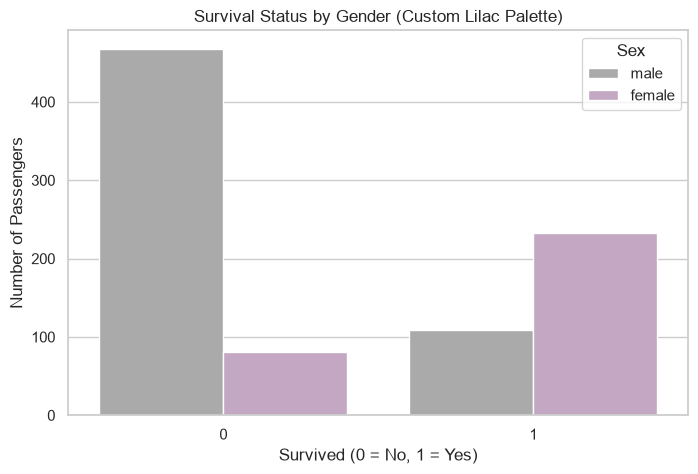

In [12]:
# Create your custom color palette (Grey and Lilac)
# #AAAAAA is Grey, #C8A2C8 is Lilac
custom_colors = ["#AAAAAA", "#C8A2C8"] 

# Draw the plot using your custom colors
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Survived', hue='Sex', palette=custom_colors)
plt.title('Survival Status by Gender (Custom Lilac Palette)')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

# Display the plot
plt.show()

In [14]:
# Reload the raw dataset to clear previous memory modifications
df = pd.read_csv('train.csv')

# Check for missing values (NaN) again
missing_data = df.isnull().sum()

# Display the results
print("Missing values in each column (Raw Data):")
print(missing_data)

Missing values in each column (Raw Data):
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [15]:
# Drop the 'Cabin' column because it has too many missing values
df = df.drop('Cabin', axis=1)

# Check the remaining columns to confirm 'Cabin' is gone
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')


In [16]:
# Fill missing 'Age' values with the median age of all passengers
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing 'Embarked' values with the most common port ('S')
df['Embarked'] = df['Embarked'].fillna('S')

# Check for missing values again to confirm everything is clean!
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [18]:
# Calculate survival rate by gender and format as percentage
survival_rates = df.groupby('Sex')['Survived'].mean() * 100

# Round the result to 1 decimal place for better readability
survival_rates = survival_rates.round(1)

print("Survival Rates by Gender (%):")
print(survival_rates)

Survival Rates by Gender (%):
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


In [19]:
# Calculate survival rate by passenger class and format as percentage
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
class_survival = class_survival.round(1)

print("Survival Rates by Passenger Class (%):")
print(class_survival)

Survival Rates by Passenger Class (%):
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64
